Sales Prediction Dataset

Dataset shape : (200, 4)
Rows : 200
Columns : 4

Columns:
TV, radio, newspaper, sales

Missing Values : 0
Duplicate Records : 0
Memory usage:6.38 KB

Statistical summary:
           TV   radio  newspaper   sales
count  200.00  200.00     200.00  200.00
mean   147.04   23.26      30.55   14.02
std     85.85   14.85      21.78    5.22
min      0.70    0.00       0.30    1.60
25%     74.38    9.98      12.75   10.38
50%    149.75   22.90      25.75   12.90
75%    218.82   36.52      45.10   17.40
max    296.40   49.60     114.00   27.00


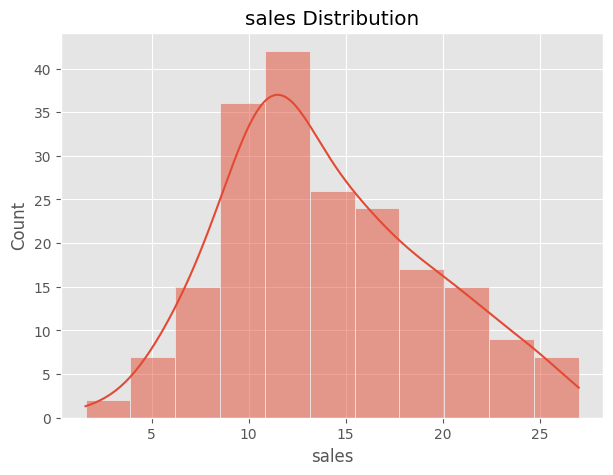

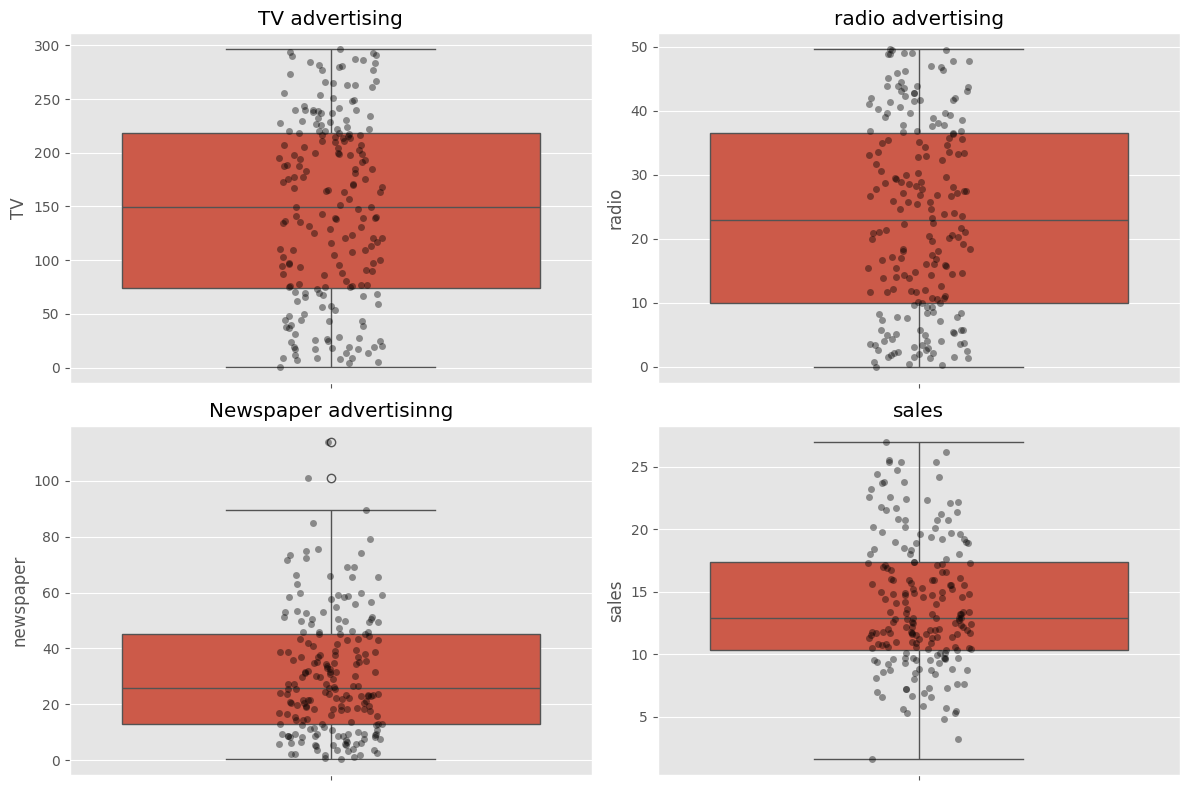

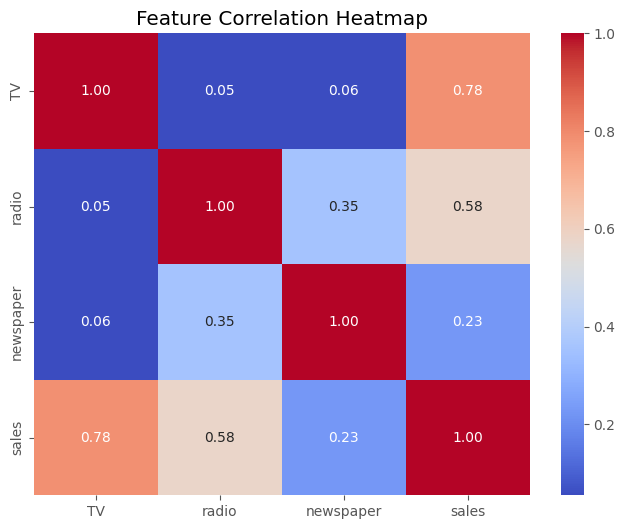

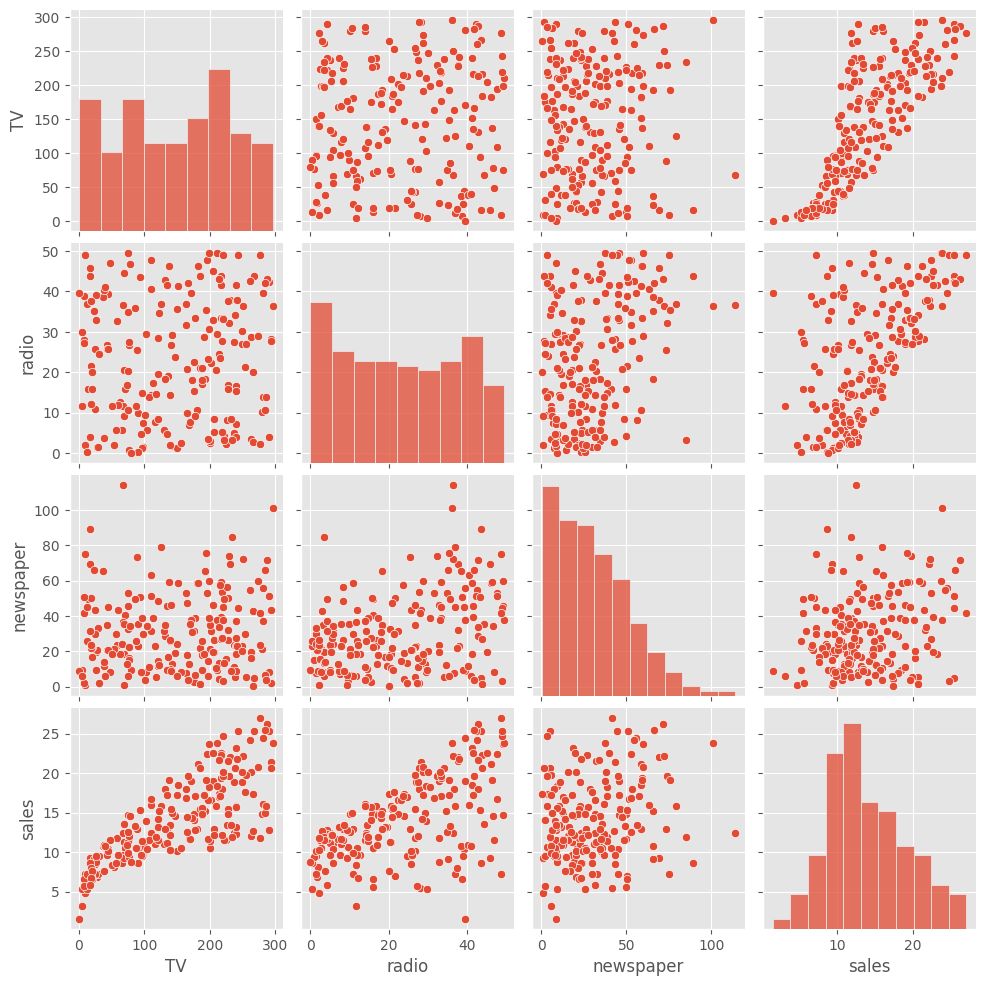


Feature engineering: Total_Advertising

Features used for training
['TV', 'radio', 'newspaper', 'Total_Advertising']

Training Shape : (160, 4)
Testing Shape : (40, 4)

LINEAR REGRESSION RESULTS
MAE : 1.4607567168117608
RMSE : 1.7815996615334506
R2 Score : 0.8994380241009119

RANDOM FOREST RESULTS
MAE : 0.8719218667831369
RMSE : 1.097705570846081
R2 Score : 0.9618244509858286

Sample predictions
   Actual sales  Predicted sales
0          16.9            17.93
1          22.4            21.58
2          21.4            21.77
3           7.3             6.90
4          24.7            22.29
5          12.6            13.55
6          22.3            22.08
7           8.4             9.53
8          11.5            11.85
9          14.9            15.55

CROSS VALIDATION
Linear Regression CV Mean: 0.887
Random Forest CV Mean: 0.97

MODEL COMPARISON
               Model  R2 Score
1      Random Forest  0.961824
0  Linear Regression  0.899438


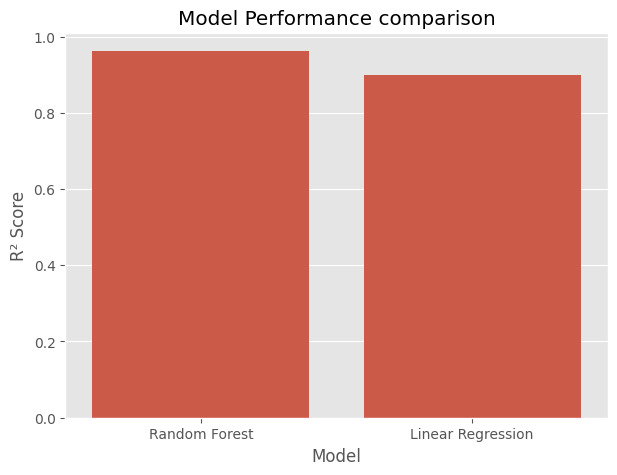


Feature Importance
             Feature  Importance
3  Total_Advertising    0.646365
1              radio    0.258722
0                 TV    0.087302
2          newspaper    0.007611


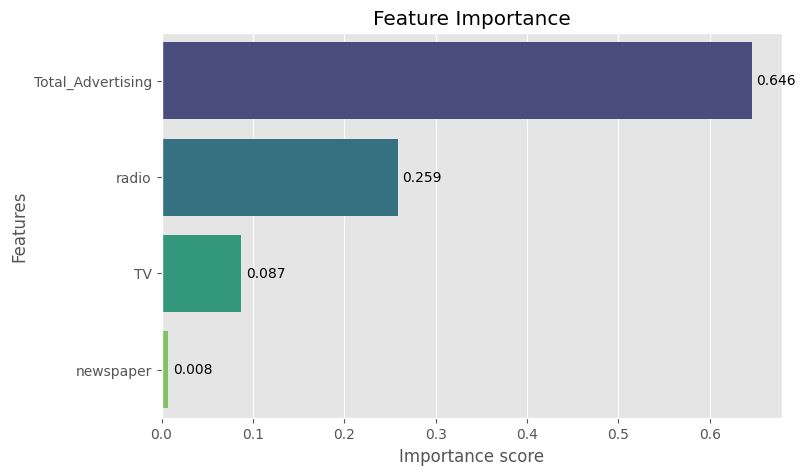


Most Important Feature: Total_Advertising


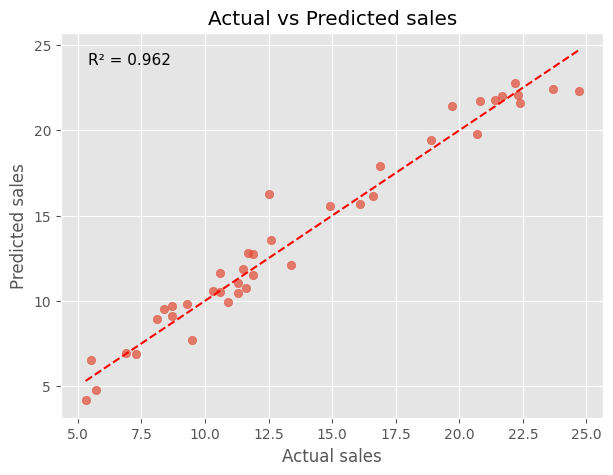

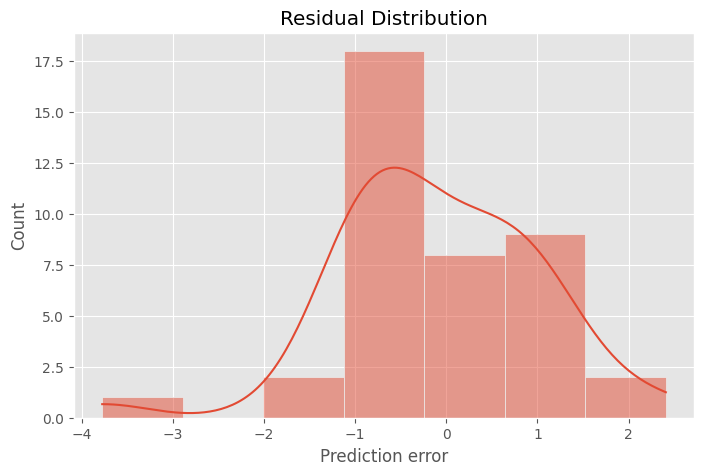


Predicted sales : 15.5


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")


# LOAD DATASET

DATA_URL = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(DATA_URL)


if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

df.columns = df.columns.str.strip()

print("=" * 50)
print("Sales Prediction Dataset")
print("=" * 50)
print()
print(f"Dataset shape : {df.shape}")
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumns:")
print(", ".join(df.columns))
print()

print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicate Records : {df.duplicated().sum()}")

print(
    f"Memory usage:"
    f"{round(df.memory_usage(deep=True).sum()/1024,2)} KB"
)
print()

print("=" * 50)
print("Statistical summary:")
print("=" * 50)
print(df.describe().round(2))

# DATA VISUALIZATION

plt.figure(figsize=(7,5))
sns.histplot(df["sales"], kde=True)
plt.title("sales Distribution")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.boxplot(y=df["TV"], ax=axes[0,0])
sns.stripplot(y=df["TV"], ax=axes[0,0], color="black", alpha=0.4, jitter=True)
axes[0,0].set_title("TV advertising")

sns.boxplot(y=df["radio"], ax=axes[0,1])
sns.stripplot(y=df["radio"], ax=axes[0,1], color="black", alpha=0.4, jitter=True)
axes[0,1].set_title("radio advertising")

sns.boxplot(y=df["newspaper"], ax=axes[1,0])
sns.stripplot(y=df["newspaper"], ax=axes[1,0], color="black", alpha=0.4, jitter=True)
axes[1,0].set_title("Newspaper advertisinng")

sns.boxplot(y=df["sales"], ax=axes[1,1])
sns.stripplot(y=df["sales"], ax=axes[1,1], color="black", alpha=0.4, jitter=True)
axes[1,1].set_title("sales")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Feature Correlation Heatmap")
plt.show()

sns.pairplot(df)
plt.show()


# FEATURES & TARGET
df["Total_Advertising"] = (
    df["TV"] +
    df["radio"] +
    df["newspaper"]
)
print("\nFeature engineering: Total_Advertising")
X = df.drop("sales", axis=1)
y = df["sales"]

print("\nFeatures used for training")
print(list(X.columns))

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

# LINEAR REGRESSION

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("\n" + "="*50)
print("LINEAR REGRESSION RESULTS")
print("="*50)

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score :", r2_score(y_test, lr_pred))


# RANDOM FOREST REGRESSOR

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\n" + "="*50)
print("RANDOM FOREST RESULTS")
print("="*50)

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

#prediction table
prediction_df = pd.DataFrame({
    "Actual sales": y_test.values,
    "Predicted sales": np.round(rf_pred,2)
})
print("\nSample predictions")
print(prediction_df.head(10))

# CROSS VALIDATION

lr_cv = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

rf_cv = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\n" + "="*50)
print("CROSS VALIDATION")
print("="*50)

print("Linear Regression CV Mean:",
      round(lr_cv.mean(),3))

print("Random Forest CV Mean:",
      round(rf_cv.mean(),3))

# MODEL COMPARISON
comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest"
    ],
    "R2 Score":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
)

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

print(comparison)

plt.figure(figsize=(7,5))
sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)
plt.title("Model Performance comparison")
plt.ylabel("R² Score")
plt.show()


# FEATURE IMPORTANCE

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print("\nFeature Importance")
print(importance)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)
for i, value in enumerate(importance["Importance"]):
  ax.text(
      value + 0.005,
      i,
      f"{value:.3f}",
      va="center"
  )

plt.title("Feature Importance")
plt.xlabel("Importance score")
plt.ylabel("Features")
plt.show()

print(
    "\nMost Important Feature:",
    importance.iloc[0]["Feature"]
)


# ACTUAL VS PREDICTED
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.text(
    0.05,
    0.95,
    f"R² = {r2_score(y_test, rf_pred):.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top"
)

plt.xlabel("Actual sales")
plt.ylabel("Predicted sales")
plt.title("Actual vs Predicted sales")
plt.show()

residuals = y_test - rf_pred
plt.figure(figsize=(8,5))
sns.histplot(
    residuals,
    kde=True
)
plt.title("Residual Distribution")
plt.xlabel("Prediction error")
plt.show()

# CUSTOM PREDICTION

sample = pd.DataFrame({
    "TV":[150],
    "radio":[25],
    "newspaper":[30],
    "Total_Advertising": [150 + 25 + 30]
})

prediction = rf_model.predict(sample)

print("\nPredicted sales :",
      round(prediction[0],2))